# Microscale Housing Recovery: FHFA House Price Index Analysis

**Methodology adapted from** the Longitudinal Housing Recovery project (Hurricane Sandy),
which used donor-based counterfactual trajectories to measure recovery at the parcel level.

**Adaptation**: We use FHFA's ZIP-level and census-tract-level House Price Index (HPI)
as a repeat-sales measure of housing market dynamics. The donor-counterfactual approach
benchmarks flooded areas against non-flooded neighbors sharing the same regional market.

**Key idea**: A flooded ZIP's HPI may drop below its expected trajectory (based on donor
ZIP growth rates). The *recovery gap* measures how long it takes to close this shortfall.

**Data**: FHFA All-Transactions HPI at 5-digit ZIP code level (annual, repeat-sales
on Fannie Mae/Freddie Mac mortgages). Coverage back to the 1980s for established ZIPs.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.utils.file_io import load_parquet

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Load FHFA ZIP5 HPI

In [2]:
# Load FHFA ZIP5 HPI (skip header rows)
raw = pd.read_excel('../data/raw/fhfa_hpi/hpi_at_zip5.xlsx', dtype=str, header=None,
                     skiprows=6)  # first 6 rows are title/notes
raw.columns = ['zip', 'year', 'annual_change', 'hpi', 'hpi1990', 'hpi2000']

# Convert types
raw['year'] = pd.to_numeric(raw['year'], errors='coerce').astype('Int64')
for col in ['annual_change', 'hpi', 'hpi1990', 'hpi2000']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

raw = raw.dropna(subset=['zip', 'year'])
raw['zip'] = raw['zip'].str.strip().str.zfill(5)

print(f'Full FHFA ZIP5 dataset: {raw.shape[0]:,} rows, {raw["zip"].nunique():,} ZIPs')
print(f'Year range: {raw["year"].min()}–{raw["year"].max()}')

Full FHFA ZIP5 dataset: 668,175 rows, 18,956 ZIPs
Year range: 1975–2024


## 2. NFIP Damage Crosswalk (ZIP level)

In [3]:
# Load NFIP claims, compute damage by ZIP
nfip = load_parquet('../data/raw/fema_nfip/nfip_tx_1998.parquet')
nfip['dateOfLoss'] = pd.to_datetime(nfip['dateOfLoss'], errors='coerce')

flood = nfip[
    (nfip['countyCode'] == '48091') &
    (nfip['dateOfLoss'] >= '1998-10-01') &
    (nfip['dateOfLoss'] <= '1998-11-30')
].copy()

for col in ['amountPaidOnBuildingClaim', 'amountPaidOnContentsClaim',
            'amountPaidOnIncreasedCostOfComplianceClaim']:
    flood[col] = pd.to_numeric(flood[col], errors='coerce').fillna(0)

flood['total_paid'] = (
    flood['amountPaidOnBuildingClaim'] +
    flood['amountPaidOnContentsClaim'] +
    flood['amountPaidOnIncreasedCostOfComplianceClaim']
)

damage_zip = flood.groupby('reportedZipCode').agg(
    nfip_claims=('id', 'count'),
    nfip_total_paid=('total_paid', 'sum'),
).reset_index().rename(columns={'reportedZipCode': 'zip'})

# Treatment tiers (following Sandy project's severity-stratified approach)
damage_zip['damage_tier'] = pd.cut(
    damage_zip['nfip_total_paid'],
    bins=[-1, 100_000, 500_000, 5_000_000, np.inf],
    labels=['minimal', 'low', 'moderate', 'severe']
)
damage_zip['treated'] = (damage_zip['nfip_total_paid'] > 500_000).astype(int)
damage_zip['intensity'] = np.log1p(damage_zip['nfip_total_paid'])

print('NFIP Damage by ZIP:')
damage_zip['paid_fmt'] = damage_zip['nfip_total_paid'].apply(lambda x: f'${x:,.0f}')
print(damage_zip[['zip', 'nfip_claims', 'paid_fmt', 'damage_tier', 'treated']].to_string(index=False))

NFIP Damage by ZIP:
  zip  nfip_claims    paid_fmt damage_tier  treated
78070            1      $7,065     minimal        0
78130          173 $17,027,459      severe        1
78131           10  $1,022,178    moderate        1
78132           45  $2,572,673    moderate        1
78133           10    $127,157         low        0
78163           31  $1,682,562    moderate        1
78266            8    $106,881         low        0


## 3. Build Housing Panel

In [4]:
# Define ZIP groups
comal_zips = ['78130', '78131', '78132', '78133', '78163', '78266', '78070']
adjacent_control_zips = ['78006', '78013', '78015', '78610', '78620', '78640']
all_zips = comal_zips + adjacent_control_zips

# Filter HPI to study ZIPs
hpi = raw[raw['zip'].isin(all_zips)].copy()
hpi = hpi[hpi['year'].between(1990, 2024)].copy()

# Use hpi1990 (base = 100 in 1990) for comparability
# If hpi1990 is missing, compute from hpi column
hpi['hpi_val'] = hpi['hpi1990'].fillna(hpi['hpi'])

# Merge treatment assignment (convert damage_tier to string first to avoid categorical issues)
damage_zip['damage_tier'] = damage_zip['damage_tier'].astype(str)
hpi = hpi.merge(damage_zip[['zip', 'treated', 'damage_tier', 'intensity', 'nfip_total_paid', 'nfip_claims']],
                on='zip', how='left')
hpi['treated'] = hpi['treated'].fillna(0).astype(int)
hpi['intensity'] = hpi['intensity'].fillna(0)
hpi['nfip_total_paid'] = hpi['nfip_total_paid'].fillna(0)
hpi['damage_tier'] = hpi['damage_tier'].fillna('control')
hpi['comal'] = hpi['zip'].isin(comal_zips).astype(int)
hpi['post'] = (hpi['year'] >= 1999).astype(int)

# Log HPI
hpi['ln_hpi'] = np.log(hpi['hpi_val'])

# Labels
zip_labels = {
    '78130': 'NB Downtown', '78131': 'NB', '78132': 'NB Outskirts',
    '78133': 'Canyon Lake', '78163': 'Bulverde', '78266': 'Garden Ridge',
    '78070': 'Spring Branch',
    '78006': 'Boerne', '78013': 'Comfort', '78015': 'Fair Oaks Ranch',
    '78610': 'Buda', '78620': 'Dripping Springs', '78640': 'Kyle',
}
hpi['zip_label'] = hpi['zip'].map(zip_labels)

print(f'Housing panel: {hpi.shape[0]} rows, {hpi["zip"].nunique()} ZIPs')
print(f'Years: {hpi["year"].min()}–{hpi["year"].max()}')
print(f'Treated: {hpi[hpi["treated"]==1]["zip"].nunique()} ZIPs, Control: {hpi[hpi["treated"]==0]["zip"].nunique()} ZIPs')

Housing panel: 391 rows, 12 ZIPs
Years: 1990–2024
Treated: 3 ZIPs, Control: 9 ZIPs


## 4. Donor-Based Counterfactual (Sandy Methodology)

Following the Longitudinal Housing Recovery project:
- **Donor pool**: Control ZIPs (NFIP damage < $130K)
- **Expected trajectory**: Each treated ZIP's 1998 HPI × median growth ratio of donors
- **Recovery gap**: `G_t = HPI_treated_t / HPI_expected_t`
- Recovery when `G_t ≥ 1.0` (actual catches up to counterfactual)

In [5]:
# Compute donor growth ratios (control ZIPs only)
control_hpi = hpi[hpi['treated'] == 0].copy()

# Growth ratio: HPI_t / HPI_1998 for each control ZIP
base_1998 = control_hpi[control_hpi['year'] == 1998].set_index('zip')['hpi_val'].to_dict()
control_hpi['base_1998'] = control_hpi['zip'].map(base_1998)
control_hpi['growth_ratio'] = control_hpi['hpi_val'] / control_hpi['base_1998']

# Median donor growth ratio by year
donor_growth = control_hpi.groupby('year')['growth_ratio'].median().reset_index()
donor_growth.columns = ['year', 'donor_growth_median']

# Also compute mean and individual paths for visualization
donor_growth_mean = control_hpi.groupby('year')['growth_ratio'].mean().reset_index()
donor_growth_mean.columns = ['year', 'donor_growth_mean']
donor_growth = donor_growth.merge(donor_growth_mean, on='year')

print('=== Donor Growth Ratios (relative to 1998) ===')
for _, r in donor_growth.iterrows():
    marker = ' <-- FLOOD' if r['year'] == 1998 else ''
    print(f"  {int(r['year'])}: median = {r['donor_growth_median']:.3f}, "
          f"mean = {r['donor_growth_mean']:.3f}{marker}")

=== Donor Growth Ratios (relative to 1998) ===
  1990: median = 0.668, mean = 0.676
  1991: median = 0.712, mean = 0.714
  1992: median = 0.778, mean = 0.780
  1993: median = 0.835, mean = 0.840
  1994: median = 0.865, mean = 0.873
  1995: median = 0.919, mean = 0.915
  1996: median = 0.939, mean = 0.944
  1997: median = 0.960, mean = 0.963
  1998: median = 1.000, mean = 1.000 <-- FLOOD
  1999: median = 1.034, mean = 1.038
  2000: median = 1.093, mean = 1.098
  2001: median = 1.146, mean = 1.167
  2002: median = 1.222, mean = 1.209
  2003: median = 1.218, mean = 1.217
  2004: median = 1.255, mean = 1.253
  2005: median = 1.305, mean = 1.323
  2006: median = 1.400, mean = 1.419
  2007: median = 1.495, mean = 1.521
  2008: median = 1.520, mean = 1.548
  2009: median = 1.484, mean = 1.526
  2010: median = 1.496, mean = 1.497
  2011: median = 1.449, mean = 1.479
  2012: median = 1.475, mean = 1.511
  2013: median = 1.551, mean = 1.541
  2014: median = 1.711, mean = 1.683
  2015: median = 1

In [6]:
# Build counterfactual for treated ZIPs
treated_hpi = hpi[hpi['treated'] == 1].copy()
treated_base = treated_hpi[treated_hpi['year'] == 1998].set_index('zip')['hpi_val'].to_dict()

treated_hpi['base_1998'] = treated_hpi['zip'].map(treated_base)
treated_hpi = treated_hpi.merge(donor_growth[['year', 'donor_growth_median']], on='year')

# Expected HPI = base_1998 × donor growth
treated_hpi['hpi_expected'] = treated_hpi['base_1998'] * treated_hpi['donor_growth_median']

# Recovery gap (G_t): actual / expected
treated_hpi['recovery_gap'] = treated_hpi['hpi_val'] / treated_hpi['hpi_expected']

# Shortfall: actual - expected (in HPI points)
treated_hpi['hpi_shortfall'] = treated_hpi['hpi_val'] - treated_hpi['hpi_expected']

# Pct shortfall relative to expected
treated_hpi['pct_shortfall'] = (treated_hpi['hpi_shortfall'] / treated_hpi['hpi_expected']) * 100

print('=== Recovery Gap by Treated ZIP ===')
for z in sorted(treated_hpi['zip'].unique()):
    zdata = treated_hpi[treated_hpi['zip'] == z]
    label = zip_labels.get(z, '')
    paid = zdata['nfip_total_paid'].iloc[0]
    print(f"\n{z} ({label}, ${paid:,.0f} NFIP):")
    for _, r in zdata[zdata['year'].isin([1997, 1998, 1999, 2000, 2001, 2002, 2005, 2010, 2015, 2020])].iterrows():
        gap_pct = r['pct_shortfall']
        recovered = 'RECOVERED' if r['recovery_gap'] >= 1.0 else ''
        print(f"  {int(r['year'])}: actual={r['hpi_val']:.1f}, expected={r['hpi_expected']:.1f}, "
              f"gap={gap_pct:+.1f}% {recovered}")

=== Recovery Gap by Treated ZIP ===

78130 (NB Downtown, $17,027,459 NFIP):
  1997: actual=128.7, expected=123.0, gap=+4.6% RECOVERED
  1998: actual=128.1, expected=128.1, gap=+0.0% RECOVERED
  1999: actual=136.9, expected=132.5, gap=+3.3% RECOVERED
  2000: actual=141.3, expected=140.0, gap=+0.9% RECOVERED
  2001: actual=148.4, expected=146.9, gap=+1.0% RECOVERED
  2002: actual=153.5, expected=156.5, gap=-1.9% 
  2005: actual=170.2, expected=167.2, gap=+1.8% RECOVERED
  2010: actual=199.9, expected=191.6, gap=+4.3% RECOVERED
  2015: actual=243.1, expected=235.1, gap=+3.4% RECOVERED
  2020: actual=316.0, expected=302.6, gap=+4.4% RECOVERED

78132 (NB Outskirts, $2,572,673 NFIP):
  1997: actual=126.6, expected=123.9, gap=+2.2% RECOVERED
  1998: actual=129.0, expected=129.0, gap=+0.0% RECOVERED
  1999: actual=133.2, expected=133.4, gap=-0.2% 
  2000: actual=142.4, expected=141.0, gap=+0.9% RECOVERED
  2001: actual=146.2, expected=147.9, gap=-1.2% 
  2002: actual=150.7, expected=157.6, gap

## 5. Counterfactual Trajectory Plots (Sandy-style)

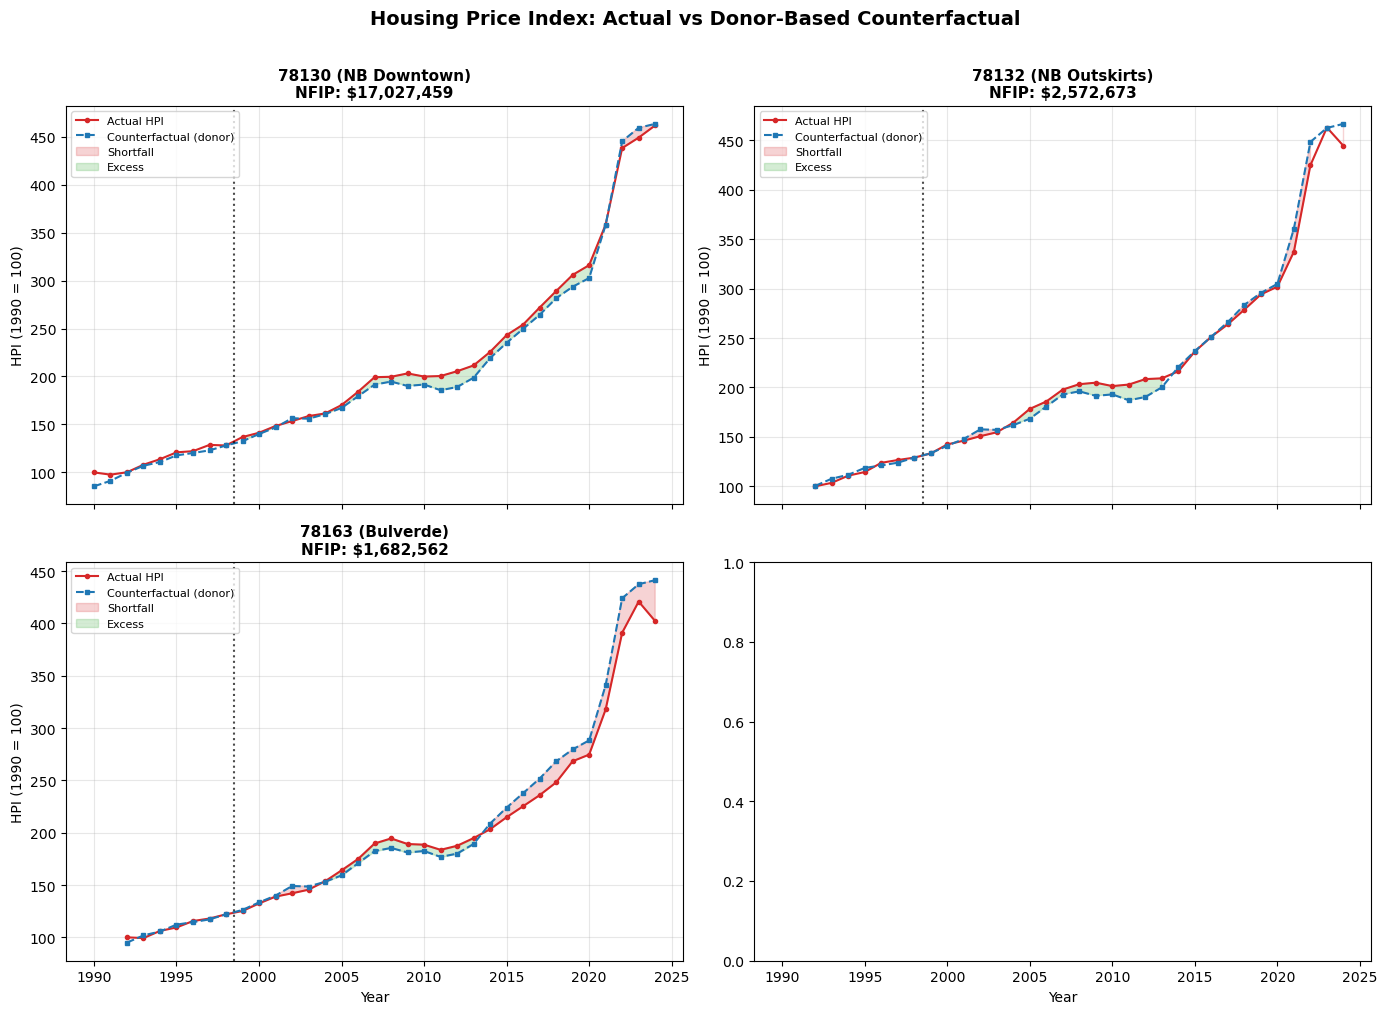

Saved: data/results/figures/hpi_counterfactual_trajectories.png


In [7]:
# Plot: Actual vs Counterfactual HPI for each treated ZIP
treated_zips = sorted(treated_hpi['zip'].unique())
n_treated = len(treated_zips)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, z in enumerate(treated_zips):
    ax = axes[i]
    zdata = treated_hpi[treated_hpi['zip'] == z]
    label = zip_labels.get(z, z)
    paid = zdata['nfip_total_paid'].iloc[0]

    ax.plot(zdata['year'], zdata['hpi_val'], 'o-', color='#d62728', markersize=3,
            linewidth=1.5, label='Actual HPI')
    ax.plot(zdata['year'], zdata['hpi_expected'], 's--', color='#1f77b4', markersize=3,
            linewidth=1.5, label='Counterfactual (donor)')

    # Shade gap in post period
    post = zdata[zdata['year'] >= 1999]
    ax.fill_between(post['year'], post['hpi_val'], post['hpi_expected'],
                    where=post['hpi_val'] < post['hpi_expected'],
                    alpha=0.2, color='#d62728', label='Shortfall')
    ax.fill_between(post['year'], post['hpi_val'], post['hpi_expected'],
                    where=post['hpi_val'] >= post['hpi_expected'],
                    alpha=0.2, color='#2ca02c', label='Excess')

    ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7)
    ax.set_title(f'{z} ({label})\nNFIP: ${paid:,.0f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('HPI (1990 = 100)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

fig.suptitle('Housing Price Index: Actual vs Donor-Based Counterfactual',
             fontsize=14, fontweight='bold', y=1.01)
axes[-1].set_xlabel('Year')
axes[-2].set_xlabel('Year')
plt.tight_layout()
plt.savefig('../data/results/figures/hpi_counterfactual_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/figures/hpi_counterfactual_trajectories.png')

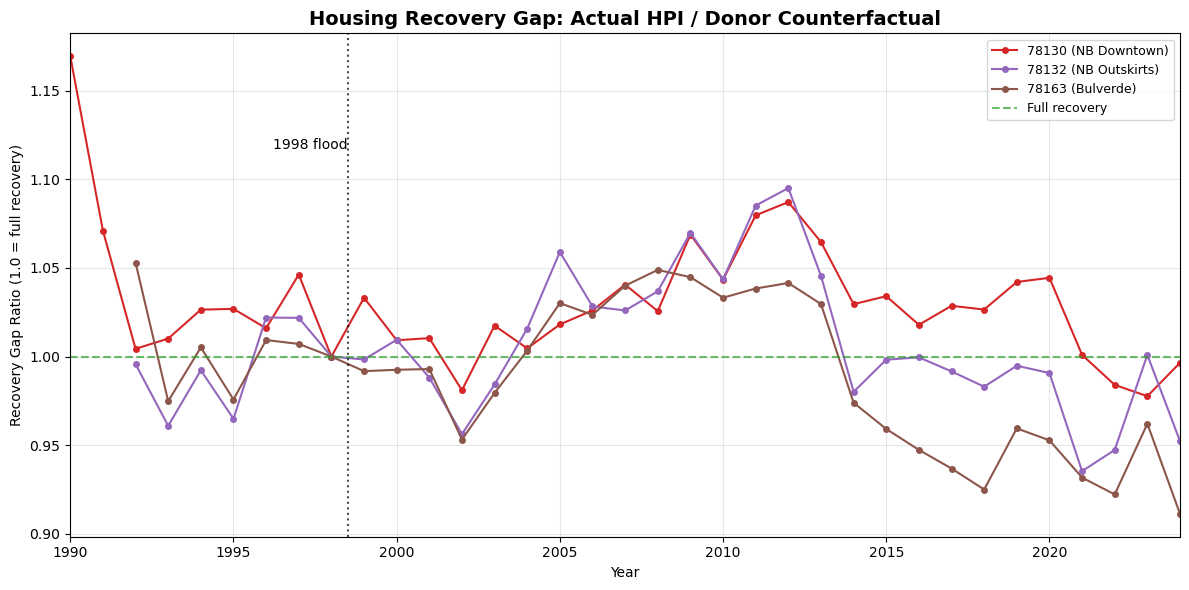

Saved: data/results/figures/hpi_recovery_gap.png


In [8]:
# Recovery gap plot (G_t = actual/expected, Sandy-style)
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'78130': '#d62728', '78131': '#ff7f0e', '78132': '#9467bd', '78163': '#8c564b'}
for z in treated_zips:
    zdata = treated_hpi[treated_hpi['zip'] == z]
    label = f"{z} ({zip_labels.get(z, '')})"    
    ax.plot(zdata['year'], zdata['recovery_gap'], 'o-', color=colors[z],
            markersize=4, linewidth=1.5, label=label)

ax.axhline(1.0, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7, label='Full recovery')
ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7)
ax.annotate('1998 flood', xy=(1998.5, ax.get_ylim()[1]*0.95),
            fontsize=10, ha='right', va='top')

ax.set_title('Housing Recovery Gap: Actual HPI / Donor Counterfactual',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Recovery Gap Ratio (1.0 = full recovery)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(1990, 2024)
plt.tight_layout()
plt.savefig('../data/results/figures/hpi_recovery_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/figures/hpi_recovery_gap.png')

## 6. All ZIPs: Raw HPI Trends

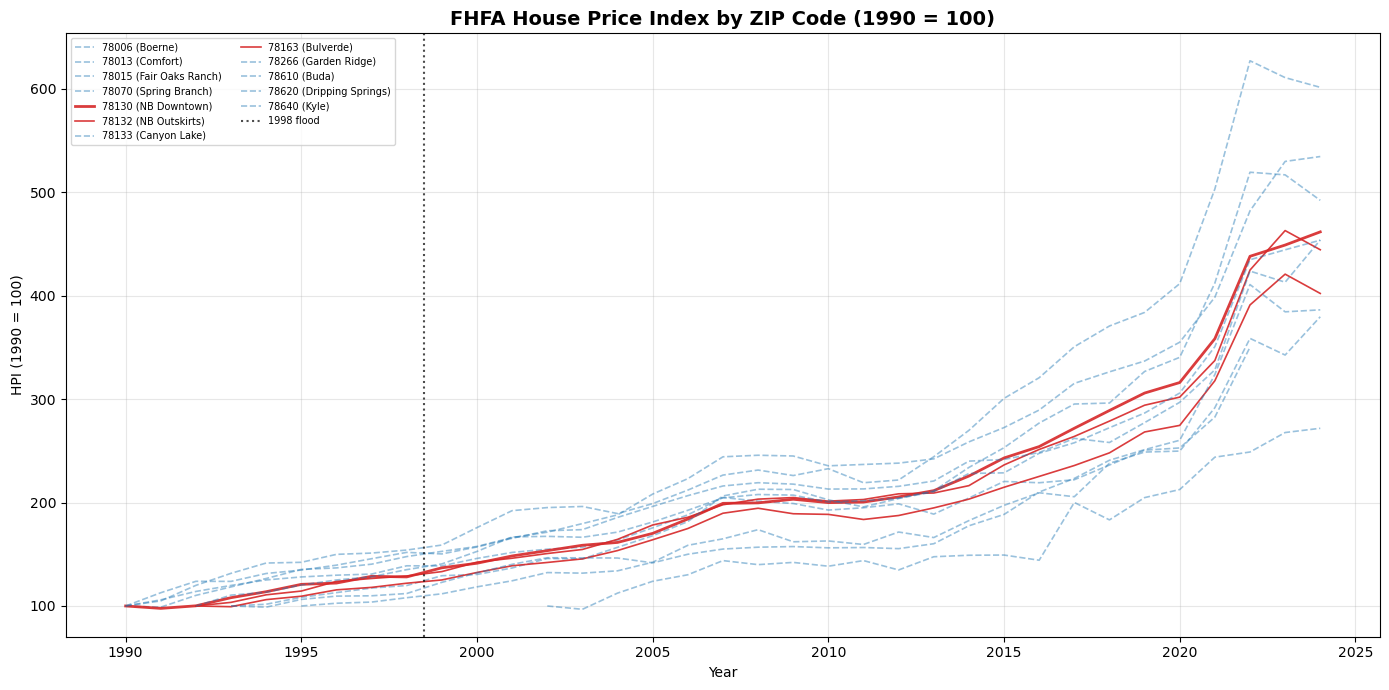

Saved: data/results/figures/hpi_all_zips.png


In [9]:
# All ZIPs on one plot
fig, ax = plt.subplots(figsize=(14, 7))

for z in sorted(hpi['zip'].unique()):
    zdata = hpi[hpi['zip'] == z]
    is_treated = zdata['treated'].iloc[0] == 1
    label = f"{z} ({zip_labels.get(z, '')})"
    color = '#d62728' if is_treated else '#1f77b4'
    ls = '-' if is_treated else '--'
    alpha = 0.9 if is_treated else 0.45
    lw = 2.0 if z == '78130' else 1.2
    ax.plot(zdata['year'], zdata['hpi_val'], ls, color=color,
            alpha=alpha, linewidth=lw, label=label)

ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7, label='1998 flood')
ax.set_title('FHFA House Price Index by ZIP Code (1990 = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('HPI (1990 = 100)')
ax.legend(fontsize=7, ncol=2, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/results/figures/hpi_all_zips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/figures/hpi_all_zips.png')

## 7. Normalized Trends (1998 = 1.0)

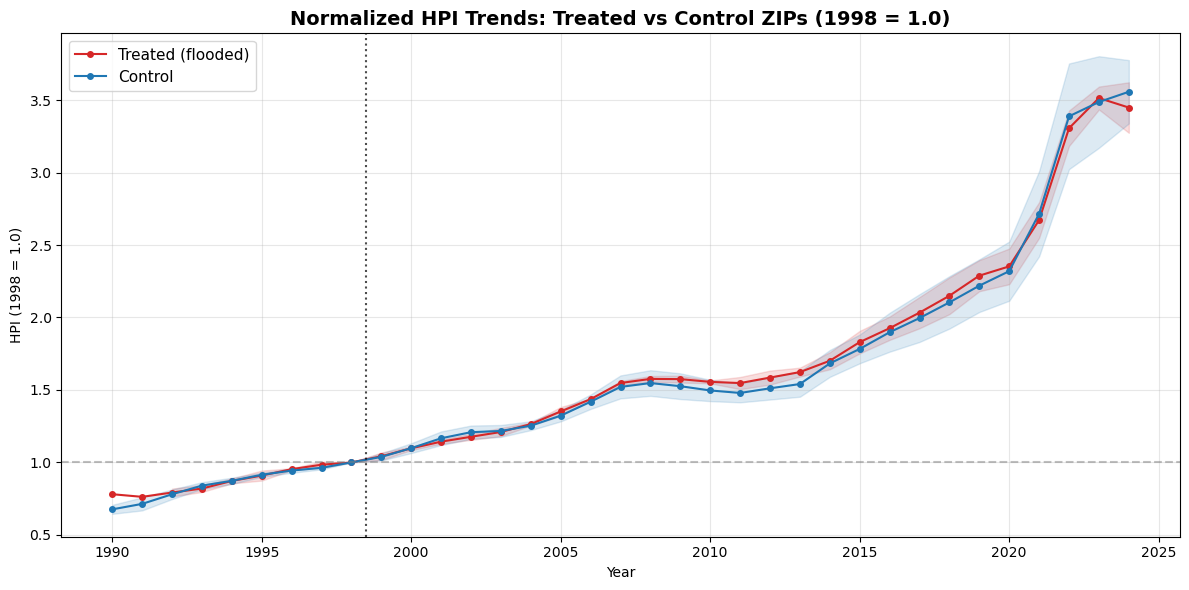

Saved: data/results/figures/hpi_normalized_trends.png


In [10]:
# Normalize all ZIPs to 1998 = 1.0 for parallel trends assessment
base_vals = hpi[hpi['year'] == 1998].set_index('zip')['hpi_val'].to_dict()
hpi['hpi_norm'] = hpi.apply(lambda r: r['hpi_val'] / base_vals.get(r['zip'], np.nan), axis=1)

# Average by treatment group
grp = hpi.groupby(['year', 'treated'])['hpi_norm'].agg(['mean', 'std', 'count']).reset_index()
grp['se'] = grp['std'] / np.sqrt(grp['count'])

fig, ax = plt.subplots(figsize=(12, 6))

for t, color, label in [(1, '#d62728', 'Treated (flooded)'), (0, '#1f77b4', 'Control')]:
    g = grp[grp['treated'] == t]
    ax.plot(g['year'], g['mean'], 'o-', color=color, markersize=4, linewidth=1.5, label=label)
    ax.fill_between(g['year'], g['mean'] - 1.96*g['se'], g['mean'] + 1.96*g['se'],
                    alpha=0.15, color=color)

ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Normalized HPI Trends: Treated vs Control ZIPs (1998 = 1.0)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('HPI (1998 = 1.0)')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/results/figures/hpi_normalized_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/figures/hpi_normalized_trends.png')

## 8. Recovery Timing Analysis (Sandy-style Survival)

In [11]:
# For each treated ZIP: year when recovery_gap first reaches 1.0 after the flood
print('=== Recovery Timing ===')
recovery_times = []
for z in treated_zips:
    zdata = treated_hpi[(treated_hpi['zip'] == z) & (treated_hpi['year'] >= 1999)]
    recovered_years = zdata[zdata['recovery_gap'] >= 1.0]['year']
    label = zip_labels.get(z, '')
    paid = zdata['nfip_total_paid'].iloc[0]
    
    if len(recovered_years) > 0:
        first_recovery = recovered_years.min()
        years_to_recover = first_recovery - 1998
        print(f"  {z} ({label}): recovered by {first_recovery} ({years_to_recover} years)")
        recovery_times.append({'zip': z, 'label': label, 'nfip_paid': paid,
                               'recovery_year': int(first_recovery), 'years_to_recover': years_to_recover})
    else:
        # Check final gap
        final_gap = zdata['recovery_gap'].iloc[-1] if len(zdata) > 0 else np.nan
        print(f"  {z} ({label}): NOT recovered by {int(zdata['year'].max())} "
              f"(final gap ratio: {final_gap:.3f})")
        recovery_times.append({'zip': z, 'label': label, 'nfip_paid': paid,
                               'recovery_year': None, 'years_to_recover': None})

recovery_df = pd.DataFrame(recovery_times)
print(f"\nMedian time to recovery: {recovery_df['years_to_recover'].median()} years")
print(f"Mean time to recovery: {recovery_df['years_to_recover'].mean():.1f} years")

=== Recovery Timing ===
  78130 (NB Downtown): recovered by 1999 (1 years)
  78132 (NB Outskirts): recovered by 2000 (2 years)
  78163 (Bulverde): recovered by 2004 (6 years)

Median time to recovery: 2.0 years
Mean time to recovery: 3.0 years


## 9. Census Tract-Level Analysis (finer resolution)

In [12]:
# Load tract-level HPI for Comal County + adjacent counties
print('Loading tract-level HPI (filtering to study area)...')
comal_prefix = '48091'
adj_prefixes = ('48209', '48259')  # Hays, Kendall

chunks = pd.read_csv('../data/raw/fhfa_hpi/hpi_at_tract.csv', dtype=str, chunksize=100000)
study_tracts = []
for chunk in chunks:
    mask = chunk['tract'].str.startswith((comal_prefix,) + adj_prefixes, na=False)
    if mask.any():
        study_tracts.append(chunk[mask])

tract_hpi = pd.concat(study_tracts)
for col in ['year', 'annual_change', 'hpi', 'hpi1990', 'hpi2000']:
    tract_hpi[col] = pd.to_numeric(tract_hpi[col], errors='coerce')
tract_hpi['year'] = tract_hpi['year'].astype(int)

# Only use tracts with pre-treatment data (start by 1996)
starts = tract_hpi.groupby('tract')['year'].min()
usable_tracts = starts[starts <= 1996].index
tract_hpi = tract_hpi[tract_hpi['tract'].isin(usable_tracts)].copy()

print(f'Usable tracts (start ≤ 1996): {len(usable_tracts)}')
print(f'  Comal: {sum(t.startswith(comal_prefix) for t in usable_tracts)}')
print(f'  Hays/Kendall: {sum(t.startswith(adj_prefixes) for t in usable_tracts)}')

Loading tract-level HPI (filtering to study area)...


Usable tracts (start ≤ 1996): 32
  Comal: 15
  Hays/Kendall: 17


In [13]:
# NFIP damage by census tract
nfip_all = load_parquet('../data/raw/fema_nfip/nfip_tx_1998.parquet')
nfip_all['dateOfLoss'] = pd.to_datetime(nfip_all['dateOfLoss'], errors='coerce')

flood_all = nfip_all[
    (nfip_all['countyCode'].isin(['48091', '48209', '48259'])) &
    (nfip_all['dateOfLoss'] >= '1998-10-01') &
    (nfip_all['dateOfLoss'] <= '1998-11-30')
].copy()

for col in ['amountPaidOnBuildingClaim', 'amountPaidOnContentsClaim',
            'amountPaidOnIncreasedCostOfComplianceClaim']:
    flood_all[col] = pd.to_numeric(flood_all[col], errors='coerce').fillna(0)
flood_all['total_paid'] = (flood_all['amountPaidOnBuildingClaim'] +
                           flood_all['amountPaidOnContentsClaim'] +
                           flood_all['amountPaidOnIncreasedCostOfComplianceClaim'])

damage_tract = flood_all.groupby('censusTract').agg(
    nfip_claims=('id', 'count'),
    nfip_total_paid=('total_paid', 'sum'),
).reset_index().rename(columns={'censusTract': 'tract'})

# Merge treatment to tract panel
tract_hpi = tract_hpi.merge(damage_tract, on='tract', how='left')
tract_hpi['nfip_total_paid'] = tract_hpi['nfip_total_paid'].fillna(0)
tract_hpi['nfip_claims'] = tract_hpi['nfip_claims'].fillna(0)
tract_hpi['treated'] = (tract_hpi['nfip_total_paid'] > 200_000).astype(int)
tract_hpi['intensity'] = np.log1p(tract_hpi['nfip_total_paid'])
tract_hpi['post'] = (tract_hpi['year'] >= 1999).astype(int)
tract_hpi['ln_hpi'] = np.log(tract_hpi['hpi'].clip(lower=1))
tract_hpi['comal'] = tract_hpi['tract'].str.startswith(comal_prefix).astype(int)

print(f'\nTract panel: {len(tract_hpi)} rows')
print(f'Treated tracts: {tract_hpi[tract_hpi["treated"]==1]["tract"].nunique()}')
print(f'Control tracts: {tract_hpi[tract_hpi["treated"]==0]["tract"].nunique()}')

# Show damage by tract for usable tracts
usable_damage = damage_tract[damage_tract['tract'].isin(usable_tracts)].sort_values('nfip_total_paid', ascending=False)
usable_damage['paid_fmt'] = usable_damage['nfip_total_paid'].apply(lambda x: f'${x:,.0f}')
print(f'\n=== Damage in usable tracts ===')
print(usable_damage[['tract', 'nfip_claims', 'paid_fmt']].to_string(index=False))


Tract panel: 1037 rows
Treated tracts: 2
Control tracts: 30

=== Damage in usable tracts ===
      tract  nfip_claims   paid_fmt
48091310503           25 $2,591,224
48091310901           11   $448,307
48091310703            3   $188,046
48091310801            8   $106,881
48091310301            1    $52,251
48091310702            1     $7,065
48091310404            2         $0
48259970500            1         $0


## 10. Save Panels for R Estimation

In [14]:
# Save ZIP-level panel
zip_out = hpi[['zip', 'year', 'zip_label', 'comal', 'hpi_val', 'ln_hpi',
               'annual_change', 'treated', 'intensity', 'post',
               'nfip_total_paid', 'nfip_claims']].copy()
zip_out = zip_out.sort_values(['zip', 'year']).reset_index(drop=True)
zip_out.to_csv('../data/processed/panels/did_hpi_zip_panel.csv', index=False)
print(f'Saved ZIP panel: {zip_out.shape} to data/processed/panels/did_hpi_zip_panel.csv')

# Save tract-level panel
tract_out = tract_hpi[['tract', 'year', 'comal', 'hpi', 'ln_hpi',
                        'annual_change', 'treated', 'intensity', 'post',
                        'nfip_total_paid', 'nfip_claims']].copy()
tract_out = tract_out.sort_values(['tract', 'year']).reset_index(drop=True)
tract_out.to_csv('../data/processed/panels/did_hpi_tract_panel.csv', index=False)
print(f'Saved tract panel: {tract_out.shape} to data/processed/panels/did_hpi_tract_panel.csv')

# Save recovery timing
recovery_df.to_csv('../data/results/hpi_recovery_timing.csv', index=False)
print(f'Saved recovery timing: data/results/hpi_recovery_timing.csv')

Saved ZIP panel: (391, 12) to data/processed/panels/did_hpi_zip_panel.csv
Saved tract panel: (1037, 11) to data/processed/panels/did_hpi_tract_panel.csv
Saved recovery timing: data/results/hpi_recovery_timing.csv


## Next Steps

Run `R/04_did_hpi.R` for:
1. **ZIP-level DiD**: `feols(ln_hpi ~ treated:post | zip + year)` — average treatment effect on housing values
2. **Event study**: `feols(ln_hpi ~ i(year, treated, ref=1998) | zip + year)` — dynamic effects
3. **Continuous intensity**: Dose-response by NFIP damage amount
4. **Tract-level robustness**: Finer geographic resolution where data permits
5. **Donor-adjusted recovery**: Time-to-recovery analysis